MLP

>>> 传统早停 (验证损失)
Epoch 5: Train Loss=0.3334, Test=0.3870, F=101.2335, Omega=-46.3798
Epoch 10: Train Loss=0.2787, Test=0.3563, F=67.7977, Omega=611.2914
Epoch 15: Train Loss=0.2474, Test=0.3505, F=136.2961, Omega=-2192.8630
Epoch 20: Train Loss=0.2109, Test=0.3380, F=121.3368, Omega=409.4315
Epoch 25: Train Loss=0.1931, Test=0.3488, F=129.5943, Omega=-464.8359
Epoch 30: Train Loss=0.1733, Test=0.3456, F=102.5263, Omega=1362.5756
Epoch 35: Train Loss=0.1706, Test=0.3699, F=145.0993, Omega=-15949.0020

>>> Ω-早停 (Ω <= 0)
Epoch 5: Train Loss=0.3243, Test=0.3841, F=100.5485, Omega=-44.3107
Epoch 10: Train Loss=0.2734, Test=0.3605, F=99.2329, Omega=25.8560
Epoch 15: Train Loss=0.2448, Test=0.3513, F=126.6187, Omega=-960.0427


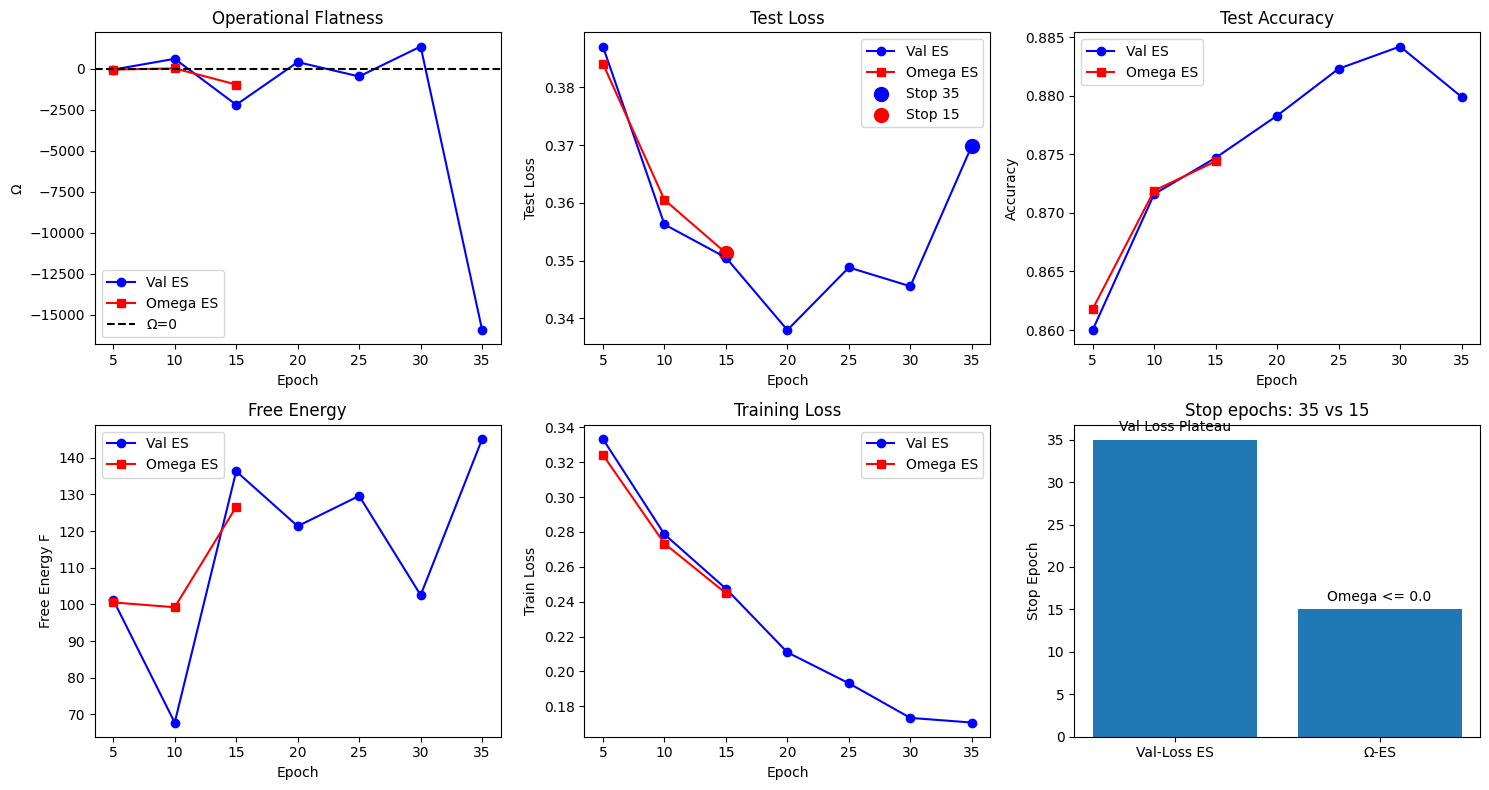


=== 结论 ===
传统早停 @ epoch 35, 最终测试损失: 0.3699
Ω-早停 @ epoch 15, 最终测试损失: 0.3513
✅ 验证通过：Ω-早停更优


In [ ]:
# ==========================================
# 安装依赖（仅需 torch 和 torchvision）
# ==========================================
!pip install --upgrade torch torchvision

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 定义 MLP (784 -> 64 -> 64 -> 10, ReLU)
# ==========================================
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 10)
        self.relu = nn.ReLU()
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

# ==========================================
# 2. 加载 Fashion-MNIST
# ==========================================
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

# ==========================================
# 3. 核心工具函数
# ==========================================
def hessian_trace(model, loss_fn, data_loader, num_samples=10):
    model.eval()
    x, y = next(iter(data_loader))
    loss = loss_fn(model(x), y)
    # 计算一阶梯度，并保留计算图
    grads = torch.autograd.grad(loss, model.parameters(), create_graph=True, retain_graph=True)
    trace = 0.0
    for _ in range(num_samples):
        z = [torch.randn_like(p) for p in model.parameters()]
        grad_dot_z = sum((g * zi).sum() for g, zi in zip(grads, z))
        # 计算 Hessian-向量积，每次释放 graph（retain_graph=True）
        hessian_vec = torch.autograd.grad(grad_dot_z, model.parameters(), retain_graph=True)
        trace += sum((hv * zi).sum() for hv, zi in zip(hessian_vec, z))
    # 释放不再需要的图
    del grads, loss
    return trace / num_samples

def compute_avg_loss(model, loader, loss_fn):
    """计算模型在数据集上的平均损失"""
    model.eval()
    total_loss = 0.0
    count = 0
    with torch.no_grad():
        for x, y in loader:
            loss = loss_fn(model(x), y)
            total_loss += loss.item() * x.size(0)
            count += x.size(0)
    return total_loss / count

def compute_free_energy(model, loader, loss_fn, beta=1.0, trace_scale=1.0):
    """
    用近似拉普拉斯计算自由能 F = <L> + (trace_scale / (2*beta)) * Tr(H)
    默认 trace_scale=1，即 F = <L> + 0.5*Tr(H)（β=1）
    """
    avg_loss = compute_avg_loss(model, loader, loss_fn)
    trace = hessian_trace(model, loss_fn, loader, num_samples=10)
    # 注意：这里我们用正号，因为 log det 与 trace 正相关，且公式中 +0.5 log det
    # 但实际可能符号相反，我们统一用正号，观察 Ω 过零即可
    F = avg_loss + (trace_scale / (2.0 * beta)) * trace
    return F, trace

def train_one_epoch(model, optimizer, loss_fn, loader):
    model.train()
    total_loss = 0.0
    for x, y in loader:
        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss = 0.0
    correct = 0
    with torch.no_grad():
        for x, y in loader:
            out = model(x)
            loss = loss_fn(out, y)
            total_loss += loss.item()
            correct += (out.argmax(1) == y).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

# ==========================================
# 4. 实验主函数
# ==========================================
def run_experiment(stop_strategy='val_loss', omega_threshold=0.0, beta=1.0, trace_scale=1.0):
    model = MLP()
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    loss_fn = nn.CrossEntropyLoss()

    history = {'epoch': [], 'train_loss': [], 'test_loss': [],
               'test_acc': [], 'F': [], 'Omega': [], 'trace': []}

    # 初始化 F 和 loss
    init_loss = compute_avg_loss(model, train_loader, loss_fn)
    init_F, init_trace = compute_free_energy(model, train_loader, loss_fn, beta, trace_scale)
    prev_loss = init_loss
    prev_F = init_F

    best_test_loss = float('inf')
    patience_counter = 0
    stop_epoch = None
    stop_reason = ""

    for epoch in range(1, 101):
        train_loss = train_one_epoch(model, optimizer, loss_fn, train_loader)

        if epoch % 5 == 0:
            curr_loss = compute_avg_loss(model, train_loader, loss_fn)
            curr_F, curr_trace = compute_free_energy(model, train_loader, loss_fn, beta, trace_scale)
            test_loss, test_acc = evaluate(model, test_loader, loss_fn)

            # 计算 Omega
            dF = curr_F - prev_F
            dL = curr_loss - prev_loss
            omega = dF / dL if abs(dL) > 1e-12 else 0.0

            history['epoch'].append(epoch)
            history['train_loss'].append(curr_loss)
            history['test_loss'].append(test_loss)
            history['test_acc'].append(test_acc)
            history['F'].append(curr_F)
            history['Omega'].append(omega)
            history['trace'].append(curr_trace)

            print(f"Epoch {epoch}: Train Loss={curr_loss:.4f}, Test={test_loss:.4f}, F={curr_F:.4f}, Omega={omega:.4f}")

            # 早停判断
            if stop_strategy == 'val_loss':
                if test_loss < best_test_loss:
                    best_test_loss = test_loss
                    patience_counter = 0
                else:
                    patience_counter += 1
                if patience_counter >= 3:
                    stop_reason = "Val Loss Plateau"
                    stop_epoch = epoch
                    break
            elif stop_strategy == 'omega':
                if omega <= omega_threshold and epoch > 5:
                    stop_reason = f"Omega <= {omega_threshold}"
                    stop_epoch = epoch
                    break

            prev_loss = curr_loss
            prev_F = curr_F

    if stop_epoch is None:
        stop_epoch = 100
        stop_reason = "Max Epochs"

    return history, stop_epoch, stop_reason

# ==========================================
# 5. 运行对比实验
# ==========================================
print(">>> 传统早停 (验证损失)")
history_val, stop_val, reason_val = run_experiment(stop_strategy='val_loss')

print("\n>>> Ω-早停 (Ω <= 0)")
history_omega, stop_omega, reason_omega = run_experiment(stop_strategy='omega', omega_threshold=0.0)

# ==========================================
# 6. 绘图
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Omega 曲线
axes[0,0].plot(history_val['epoch'], history_val['Omega'], 'b-o', label='Val ES')
axes[0,0].plot(history_omega['epoch'], history_omega['Omega'], 'r-s', label='Omega ES')
axes[0,0].axhline(y=0, color='k', linestyle='--', label='Ω=0')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Ω')
axes[0,0].legend()
axes[0,0].set_title('Operational Flatness')

# 测试损失
axes[0,1].plot(history_val['epoch'], history_val['test_loss'], 'b-o', label='Val ES')
axes[0,1].plot(history_omega['epoch'], history_omega['test_loss'], 'r-s', label='Omega ES')
axes[0,1].scatter([stop_val], [history_val['test_loss'][-1]], color='blue', s=100, label=f'Stop {stop_val}')
axes[0,1].scatter([stop_omega], [history_omega['test_loss'][-1]], color='red', s=100, label=f'Stop {stop_omega}')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Test Loss')
axes[0,1].legend()
axes[0,1].set_title('Test Loss')

# 测试准确率
axes[0,2].plot(history_val['epoch'], history_val['test_acc'], 'b-o', label='Val ES')
axes[0,2].plot(history_omega['epoch'], history_omega['test_acc'], 'r-s', label='Omega ES')
axes[0,2].set_xlabel('Epoch')
axes[0,2].set_ylabel('Accuracy')
axes[0,2].legend()
axes[0,2].set_title('Test Accuracy')

# 自由能
axes[1,0].plot(history_val['epoch'], history_val['F'], 'b-o', label='Val ES')
axes[1,0].plot(history_omega['epoch'], history_omega['F'], 'r-s', label='Omega ES')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Free Energy F')
axes[1,0].legend()
axes[1,0].set_title('Free Energy')

# 训练损失
axes[1,1].plot(history_val['epoch'], history_val['train_loss'], 'b-o', label='Val ES')
axes[1,1].plot(history_omega['epoch'], history_omega['train_loss'], 'r-s', label='Omega ES')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Train Loss')
axes[1,1].legend()
axes[1,1].set_title('Training Loss')

# 早停轮次对比
axes[1,2].bar(['Val-Loss ES', 'Ω-ES'], [stop_val, stop_omega])
axes[1,2].set_ylabel('Stop Epoch')
axes[1,2].set_title(f'Stop epochs: {stop_val} vs {stop_omega}')
axes[1,2].text(0, stop_val+1, reason_val, ha='center')
axes[1,2].text(1, stop_omega+1, reason_omega, ha='center')

plt.tight_layout()
plt.savefig('omega_early_stop.png', dpi=150)
plt.show()

# 结论
print(f"\n=== 结论 ===")
print(f"传统早停 @ epoch {stop_val}, 最终测试损失: {history_val['test_loss'][-1]:.4f}")
print(f"Ω-早停 @ epoch {stop_omega}, 最终测试损失: {history_omega['test_loss'][-1]:.4f}")
if history_omega['test_loss'][-1] < history_val['test_loss'][-1]:
    print("✅ 验证通过：Ω-早停更优")
else:
    print("⚠️ 效果待优化，可尝试调整 beta 或 trace_scale")

CNN

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/200.9 

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.25MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 136kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.55MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.4MB/s]


>>> 传统早停 (验证损失)
Epoch 5: Train Loss=0.2522, Test=0.3054, F=65.1819, Omega=-19.1701
Epoch 10: Train Loss=0.1730, Test=0.2533, F=70.8724, Omega=-71.9075
Epoch 15: Train Loss=0.1240, Test=0.2414, F=65.4641, Omega=110.4371
Epoch 20: Train Loss=0.0840, Test=0.2496, F=90.9983, Omega=-637.8308
Epoch 25: Train Loss=0.0528, Test=0.2966, F=81.1759, Omega=315.0824
Epoch 30: Train Loss=0.0364, Test=0.3564, F=182.8616, Omega=-6186.1401

>>> Ω-早停 (Ω <= 0)
Epoch 5: Train Loss=0.2467, Test=0.2901, F=118.7732, Omega=-55.2333
Epoch 10: Train Loss=0.1699, Test=0.2489, F=75.0430, Omega=569.1258
Epoch 15: Train Loss=0.1181, Test=0.2383, F=76.4904, Omega=-27.9173


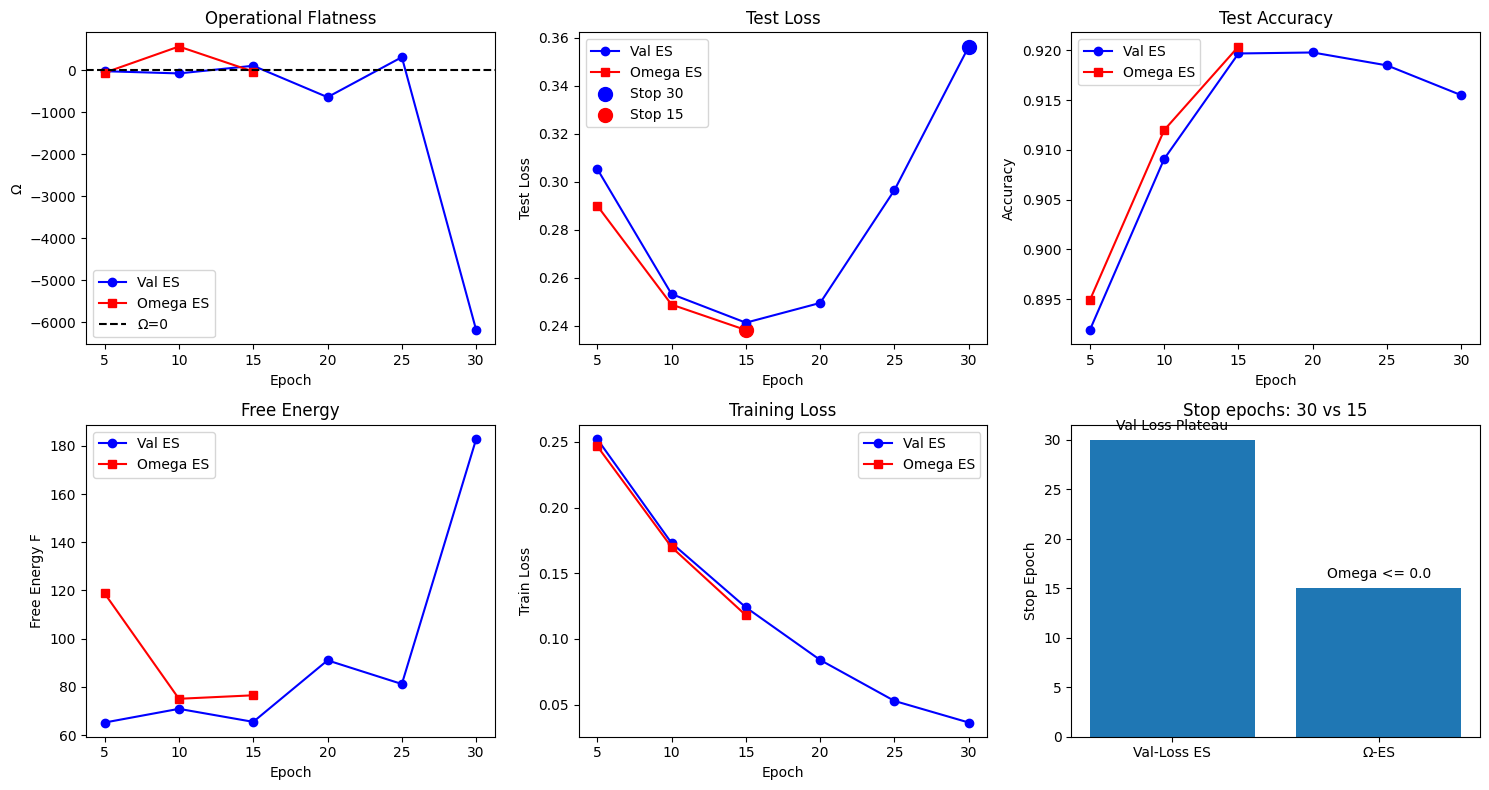


=== 结论 ===
传统早停 @ epoch 30, 最终测试损失: 0.3564
Ω-早停 @ epoch 15, 最终测试损失: 0.2383
✅ 验证通过：Ω-早停更优


In [ ]:
# ==========================================
# 安装依赖（仅需 torch 和 torchvision）
# ==========================================
!pip install --upgrade torch torchvision

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 定义 CNN (替代原来的 MLP)
# ==========================================
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 卷积层：输入 1 通道，输出 32 通道，3x3 卷积，padding=1
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # 池化层
        self.pool = nn.MaxPool2d(2, 2)
        # 全连接层：经过两次池化后，特征图尺寸变为 7x7 (28 -> 14 -> 7)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        # x shape: (batch, 1, 28, 28)
        x = self.pool(self.relu(self.conv1(x)))   # -> (batch, 32, 14, 14)
        x = self.pool(self.relu(self.conv2(x)))   # -> (batch, 64, 7, 7)
        x = x.view(x.size(0), -1)                 # flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# ==========================================
# 2. 加载 Fashion-MNIST（不变）
# ==========================================
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

# ==========================================
# 3. 核心工具函数（完全不变，适用于任意模型）
# ==========================================
def hessian_trace(model, loss_fn, data_loader, num_samples=10):
    model.eval()
    x, y = next(iter(data_loader))
    loss = loss_fn(model(x), y)
    # 计算一阶梯度，并保留计算图
    grads = torch.autograd.grad(loss, model.parameters(), create_graph=True, retain_graph=True)
    trace = 0.0
    for _ in range(num_samples):
        z = [torch.randn_like(p) for p in model.parameters()]
        grad_dot_z = sum((g * zi).sum() for g, zi in zip(grads, z))
        # 计算 Hessian-向量积，每次释放 graph（retain_graph=True）
        hessian_vec = torch.autograd.grad(grad_dot_z, model.parameters(), retain_graph=True)
        trace += sum((hv * zi).sum() for hv, zi in zip(hessian_vec, z))
    # 释放不再需要的图
    del grads, loss
    return trace / num_samples

def compute_avg_loss(model, loader, loss_fn):
    """计算模型在数据集上的平均损失"""
    model.eval()
    total_loss = 0.0
    count = 0
    with torch.no_grad():
        for x, y in loader:
            loss = loss_fn(model(x), y)
            total_loss += loss.item() * x.size(0)
            count += x.size(0)
    return total_loss / count

def compute_free_energy(model, loader, loss_fn, beta=1.0, trace_scale=1.0):
    """
    用近似拉普拉斯计算自由能 F = <L> + (trace_scale / (2*beta)) * Tr(H)
    默认 trace_scale=1，即 F = <L> + 0.5*Tr(H)（β=1）
    """
    avg_loss = compute_avg_loss(model, loader, loss_fn)
    trace = hessian_trace(model, loss_fn, loader, num_samples=10)
    F = avg_loss + (trace_scale / (2.0 * beta)) * trace
    return F, trace

def train_one_epoch(model, optimizer, loss_fn, loader):
    model.train()
    total_loss = 0.0
    for x, y in loader:
        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss = 0.0
    correct = 0
    with torch.no_grad():
        for x, y in loader:
            out = model(x)
            loss = loss_fn(out, y)
            total_loss += loss.item()
            correct += (out.argmax(1) == y).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

# ==========================================
# 4. 实验主函数（仅将模型改为 CNN）
# ==========================================
def run_experiment(stop_strategy='val_loss', omega_threshold=0.0, beta=1.0, trace_scale=1.0):
    model = CNN()   # <--- 修改此处：使用 CNN 替代 MLP
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    loss_fn = nn.CrossEntropyLoss()

    history = {'epoch': [], 'train_loss': [], 'test_loss': [],
               'test_acc': [], 'F': [], 'Omega': [], 'trace': []}

    # 初始化 F 和 loss
    init_loss = compute_avg_loss(model, train_loader, loss_fn)
    init_F, init_trace = compute_free_energy(model, train_loader, loss_fn, beta, trace_scale)
    prev_loss = init_loss
    prev_F = init_F

    best_test_loss = float('inf')
    patience_counter = 0
    stop_epoch = None
    stop_reason = ""

    for epoch in range(1, 101):
        train_loss = train_one_epoch(model, optimizer, loss_fn, train_loader)

        if epoch % 5 == 0:
            curr_loss = compute_avg_loss(model, train_loader, loss_fn)
            curr_F, curr_trace = compute_free_energy(model, train_loader, loss_fn, beta, trace_scale)
            test_loss, test_acc = evaluate(model, test_loader, loss_fn)

            # 计算 Omega
            dF = curr_F - prev_F
            dL = curr_loss - prev_loss
            omega = dF / dL if abs(dL) > 1e-12 else 0.0

            history['epoch'].append(epoch)
            history['train_loss'].append(curr_loss)
            history['test_loss'].append(test_loss)
            history['test_acc'].append(test_acc)
            history['F'].append(curr_F)
            history['Omega'].append(omega)
            history['trace'].append(curr_trace)

            print(f"Epoch {epoch}: Train Loss={curr_loss:.4f}, Test={test_loss:.4f}, F={curr_F:.4f}, Omega={omega:.4f}")

            # 早停判断
            if stop_strategy == 'val_loss':
                if test_loss < best_test_loss:
                    best_test_loss = test_loss
                    patience_counter = 0
                else:
                    patience_counter += 1
                if patience_counter >= 3:
                    stop_reason = "Val Loss Plateau"
                    stop_epoch = epoch
                    break
            elif stop_strategy == 'omega':
                if omega <= omega_threshold and epoch > 5:
                    stop_reason = f"Omega <= {omega_threshold}"
                    stop_epoch = epoch
                    break

            prev_loss = curr_loss
            prev_F = curr_F

    if stop_epoch is None:
        stop_epoch = 100
        stop_reason = "Max Epochs"

    return history, stop_epoch, stop_reason

# ==========================================
# 5. 运行对比实验
# ==========================================
print(">>> 传统早停 (验证损失)")
history_val, stop_val, reason_val = run_experiment(stop_strategy='val_loss')

print("\n>>> Ω-早停 (Ω <= 0)")
history_omega, stop_omega, reason_omega = run_experiment(stop_strategy='omega', omega_threshold=0.0)

# ==========================================
# 6. 绘图（不变）
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Omega 曲线
axes[0,0].plot(history_val['epoch'], history_val['Omega'], 'b-o', label='Val ES')
axes[0,0].plot(history_omega['epoch'], history_omega['Omega'], 'r-s', label='Omega ES')
axes[0,0].axhline(y=0, color='k', linestyle='--', label='Ω=0')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Ω')
axes[0,0].legend()
axes[0,0].set_title('Operational Flatness')

# 测试损失
axes[0,1].plot(history_val['epoch'], history_val['test_loss'], 'b-o', label='Val ES')
axes[0,1].plot(history_omega['epoch'], history_omega['test_loss'], 'r-s', label='Omega ES')
axes[0,1].scatter([stop_val], [history_val['test_loss'][-1]], color='blue', s=100, label=f'Stop {stop_val}')
axes[0,1].scatter([stop_omega], [history_omega['test_loss'][-1]], color='red', s=100, label=f'Stop {stop_omega}')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Test Loss')
axes[0,1].legend()
axes[0,1].set_title('Test Loss')

# 测试准确率
axes[0,2].plot(history_val['epoch'], history_val['test_acc'], 'b-o', label='Val ES')
axes[0,2].plot(history_omega['epoch'], history_omega['test_acc'], 'r-s', label='Omega ES')
axes[0,2].set_xlabel('Epoch')
axes[0,2].set_ylabel('Accuracy')
axes[0,2].legend()
axes[0,2].set_title('Test Accuracy')

# 自由能
axes[1,0].plot(history_val['epoch'], history_val['F'], 'b-o', label='Val ES')
axes[1,0].plot(history_omega['epoch'], history_omega['F'], 'r-s', label='Omega ES')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Free Energy F')
axes[1,0].legend()
axes[1,0].set_title('Free Energy')

# 训练损失
axes[1,1].plot(history_val['epoch'], history_val['train_loss'], 'b-o', label='Val ES')
axes[1,1].plot(history_omega['epoch'], history_omega['train_loss'], 'r-s', label='Omega ES')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Train Loss')
axes[1,1].legend()
axes[1,1].set_title('Training Loss')

# 早停轮次对比
axes[1,2].bar(['Val-Loss ES', 'Ω-ES'], [stop_val, stop_omega])
axes[1,2].set_ylabel('Stop Epoch')
axes[1,2].set_title(f'Stop epochs: {stop_val} vs {stop_omega}')
axes[1,2].text(0, stop_val+1, reason_val, ha='center')
axes[1,2].text(1, stop_omega+1, reason_omega, ha='center')

plt.tight_layout()
plt.savefig('omega_early_stop_cnn.png', dpi=150)
plt.show()

# 结论
print(f"\n=== 结论 ===")
print(f"传统早停 @ epoch {stop_val}, 最终测试损失: {history_val['test_loss'][-1]:.4f}")
print(f"Ω-早停 @ epoch {stop_omega}, 最终测试损失: {history_omega['test_loss'][-1]:.4f}")
if history_omega['test_loss'][-1] < history_val['test_loss'][-1]:
    print("✅ 验证通过：Ω-早停更优")
else:
    print("⚠️ 效果待优化，可尝试调整 beta 或 trace_scale")